# VISUALIZE DATA FROM CPP FILE

In [10]:
import numpy as np
from matplotlib import pyplot as plt
import scipy

In [11]:
#risk free rate
r = 0.05

#risk
sig = 0.2

#strike price
K = 1.

#time to maturity
T = 1.

#width of transformed S coordinate
w = 1.2

In [12]:
tau = np.linspace(0, T, 1001)
x = np.linspace(-w, w, 101)

In [7]:
data = np.loadtxt('european_call_option_data.txt')

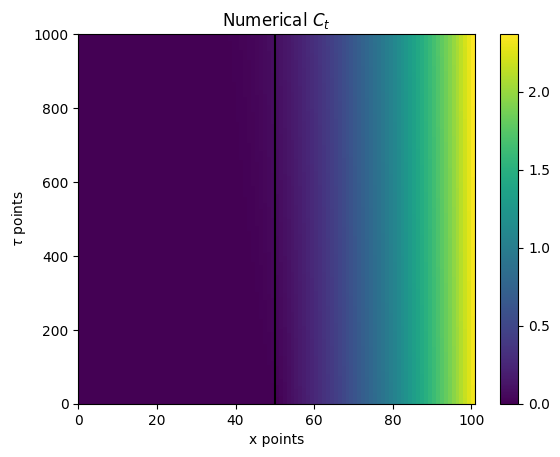

In [8]:
plt.pcolormesh(data[:, 1:])
plt.title('Numerical '+r'$C_t$')
plt.xlabel('x points')
plt.ylabel(r'$\tau$'+' points')
plt.axvline(x=50, c='black')
plt.colorbar()

In [13]:
def euro_call(x, tau, K, r, sig):
   
    d2 = (x + (r - 0.5*sig**2)*tau) / (sig*np.sqrt(tau))
    d1 = d2 + sig*np.sqrt(tau)
    return K*np.exp(x)*scipy.stats.norm.cdf(d1) - K*np.exp(-r*tau)*scipy.stats.norm.cdf(d2)

In [16]:
def call_heatmap(num_data):

  
    analytical_solution = np.zeros((len(tau), len(x)))

    for i in range(0, len(tau)):
        
        analytical_solution[i,:] = euro_call(x, tau[i], K, r, sig)
        
    errors = np.abs(num_data-  analytical_solution)

    return errors

In [17]:
errors = call_heatmap(data[:, 1:])

C:\Users\Ayush Roy\AppData\Local\Temp\ipykernel_29628\2170478369.py:3: RuntimeWarning: divide by zero encountered in divide
  d2 = (x + (r - 0.5*sig**2)*tau) / (sig*np.sqrt(tau))
C:\Users\Ayush Roy\AppData\Local\Temp\ipykernel_29628\2170478369.py:3: RuntimeWarning: invalid value encountered in divide
  d2 = (x + (r - 0.5*sig**2)*tau) / (sig*np.sqrt(tau))


C:\Users\Ayush Roy\AppData\Local\Temp\ipykernel_29628\3832645894.py:1: RuntimeWarning: divide by zero encountered in log10
  plt.pcolormesh(np.log10(errors), vmin = -17)


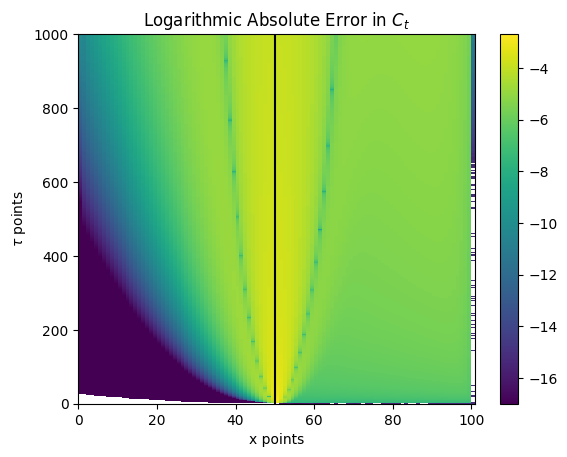

In [26]:
plt.pcolormesh(np.log10(errors), vmin = -17)
plt.title('Logarithmic Absolute Error in '+r'$C_t$')
plt.xlabel('x points')
plt.ylabel(r'$\tau$'+' points')
plt.axvline(x=50, c='black')
plt.colorbar()